# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [375]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [376]:
clean_airline=pd.read_csv("cleaned_airline_df.csv")

pd.set_option("display.max_columns", None)

clean_airline.head(3)





,investigation_type,accident_number,location,injury_severity,aircraft_damage,aircraft_category,make,model,amateur_built,number_of_engines,engine_type,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight,report_status,total_passangers,fatal_serious_inj,aircraft_destroyed,make_model
0,Incident,LAX83IA149A,"LOS ANGELES, CA",Incident,Minor,Airplane,boeing,747,No,4.0,turbo fan,0.0,0.0,0.0,588.0,VMC,taxi,Probable Cause,588.0,0.000000,0,boeing_747
1,Accident,ATL83FA140,"CROSSVILLE, TN",Fatal(1),Destroyed,Airplane,piper,PA-28-140,No,1.0,reciprocating,1.0,1.0,0.0,1.0,IMC,cruise,Probable Cause,3.0,1.333333,1,piper_pa-28-140
2,Accident,FTW83LA177,"MCKINNEY, TX",Fatal(1),unknown,Airplane,de havilland,DHC-6,No,2.0,turbo prop,1.0,0.0,0.0,4.0,VMC,standing,Probable Cause,5.0,1.000000,0,de havilland_dhc-6


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [377]:
clean_airline.columns

Index(['investigation_type', 'accident_number', 'location', 'injury_severity',
       'aircraft_damage', 'aircraft_category', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type',
       'total_fatal_injuries', 'total_serious_injuries',
       'total_minor_injuries', 'total_uninjured', 'weather_condition',
       'broad_phase_of_flight', 'report_status', 'total_passangers',
       'fatal_serious_inj', 'aircraft_destroyed', 'make_model'],
      dtype='str')

####  Separate Small vs Large Planes

In [378]:
small_planes = clean_airline[clean_airline['total_passangers'] < 20].copy()
large_planes = clean_airline[clean_airline['total_passangers'] >= 20].copy()

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

#### Small Aircraft Makes 

In [379]:
small_make_risk = (
    small_planes.groupby("make")["fatal_serious_inj"]
    .mean()
    .sort_values(ascending=True)
    .head(15)
    .reset_index()
)
small_make_risk

,make,fatal_serious_inj
0,mcdonnell douglas,0.191468
1,ayres,0.200617
2,aviat aircraft inc,0.203947
3,grumman acft eng cor-schweizer,0.206897
4,maule,0.245659
5,stinson,0.247416
6,aviat,0.257143
7,aeronca,0.264167
8,boeing,0.274240
9,bellanca,0.283866


#### Large Aircraft Makes

In [380]:
large_make_risk = (
    large_planes.groupby("make")["fatal_serious_inj"]
    .mean()
    .sort_values(ascending=True)
    .head(15)
    .reset_index()
)
large_make_risk

,make,fatal_serious_inj
0,dehavilland,0.000000
1,cessna,0.000000
2,piper,0.000000
3,grumman,0.000000
4,raytheon aircraft company,0.150000
5,mcdonnell douglas,0.439914
6,bombardier inc,1.118947
7,embraer,3.267182
8,de havilland,4.691700
9,boeing,5.821453


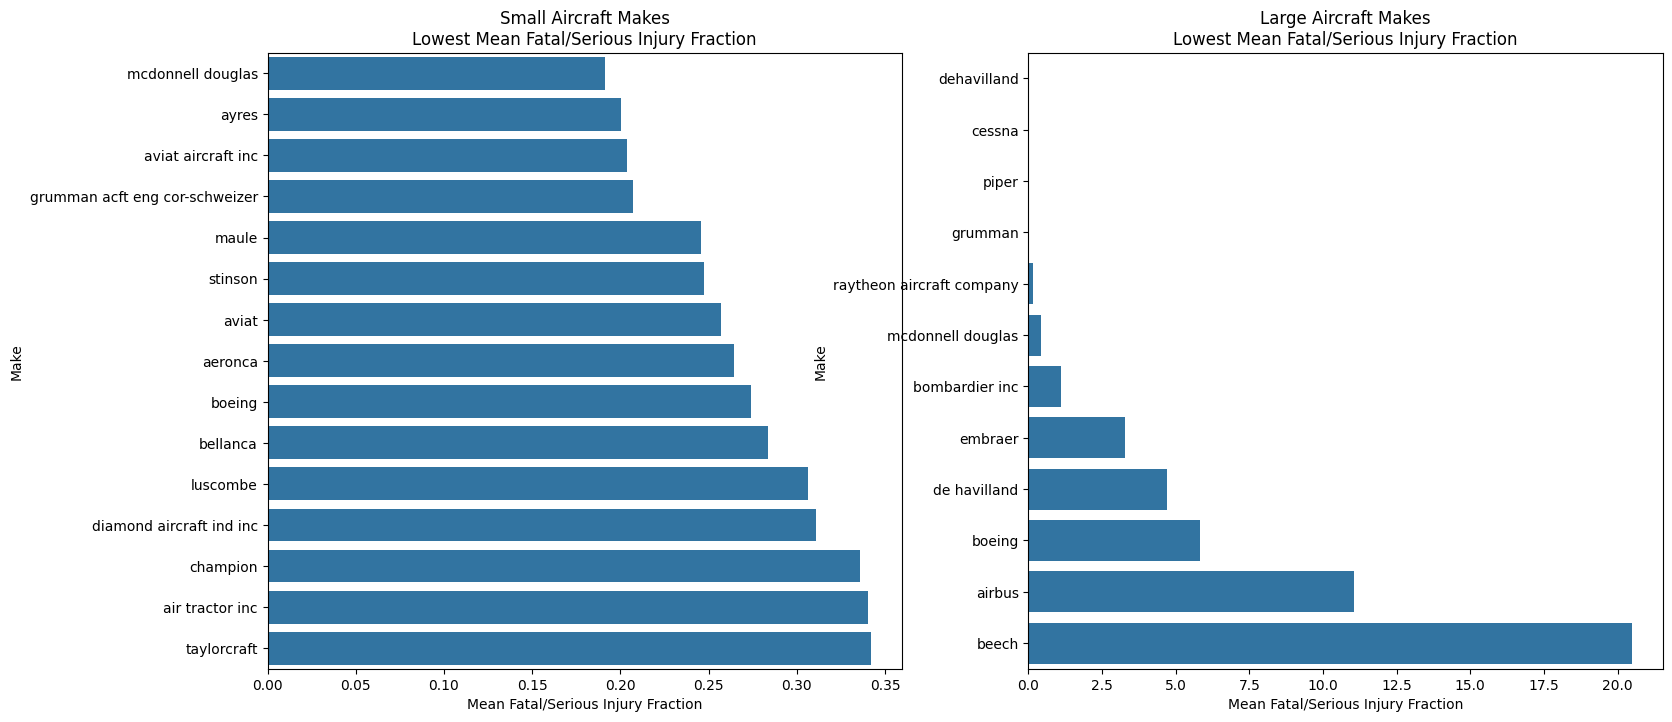

In [381]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Small aircraft plot
sns.barplot(
    data=small_make_risk,
    x="fatal_serious_inj",
    y="make",
    ax=axes[0]
)
axes[0].set_title("Small Aircraft Makes\nLowest Mean Fatal/Serious Injury Fraction")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[0].set_ylabel("Make")

# Large aircraft plot
sns.barplot(
    data=large_make_risk,
    x="fatal_serious_inj",
    y="make",
    ax=axes[1]
)

axes[1].set_title("Large Aircraft Makes\nLowest Mean Fatal/Serious Injury Fraction")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[1].set_ylabel("Make")


plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

#### Get 10 safest makes (lowest mean injury rate) and then Filter dataset for those makes( small makes)

In [382]:
#lowest mean injury rate
top10_small_makes = (
    small_planes.groupby("make")["fatal_serious_inj"]
    .mean()
    .sort_values()
    .head(10)
    .index
)
#Filter dataset for those makes
small_top10 = small_planes[small_planes["make"].isin(top10_small_makes)]


#### Violin plot (distribution of injury rates)

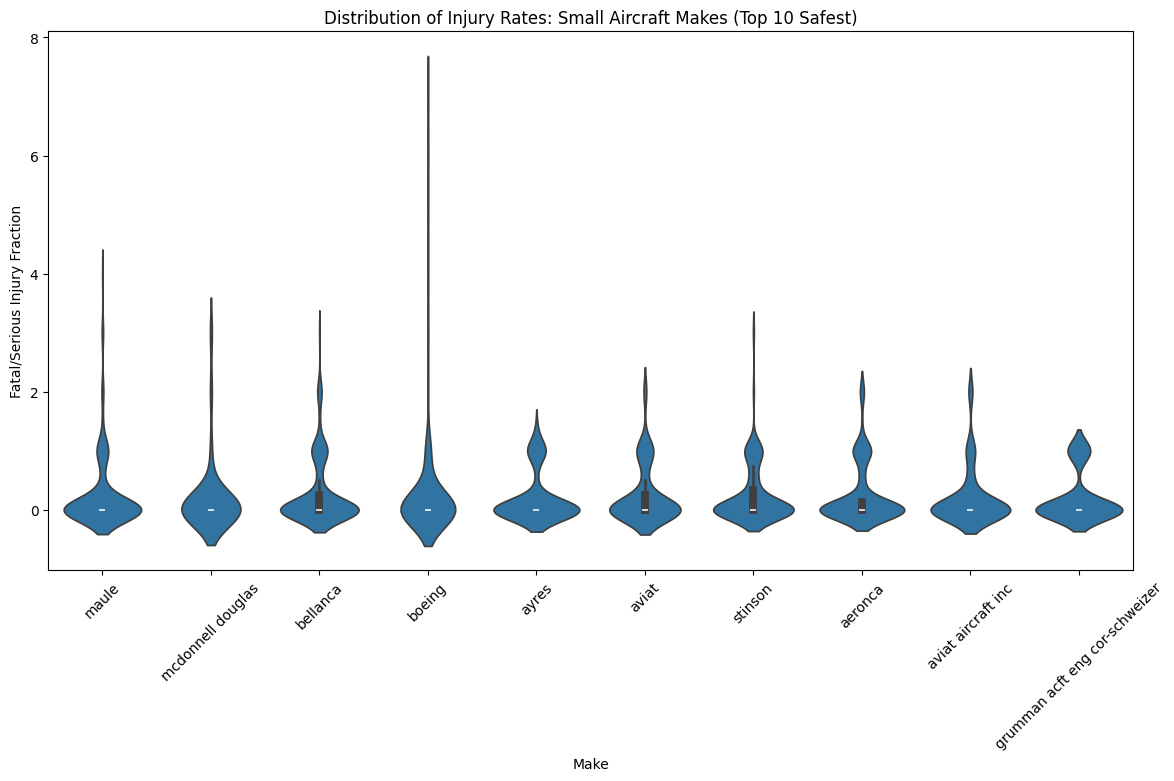

In [383]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.violinplot(
    data=small_top10,
    x="make",
    y="fatal_serious_inj"
)

plt.title("Distribution of Injury Rates: Small Aircraft Makes (Top 10 Safest)")
plt.xlabel("Make")
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xticks(rotation=45)
palette="tab10"

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

#### Get 10 safest makes (lowest mean injury rate) and then Filter dataset for those makes (large makes)


In [384]:
top10_large_makes = (
    large_planes.groupby("make")["fatal_serious_inj"]
    .mean()
    .sort_values()
    .head(10)
    .index
)
large_top10 = large_planes[large_planes["make"].isin(top10_large_makes)]



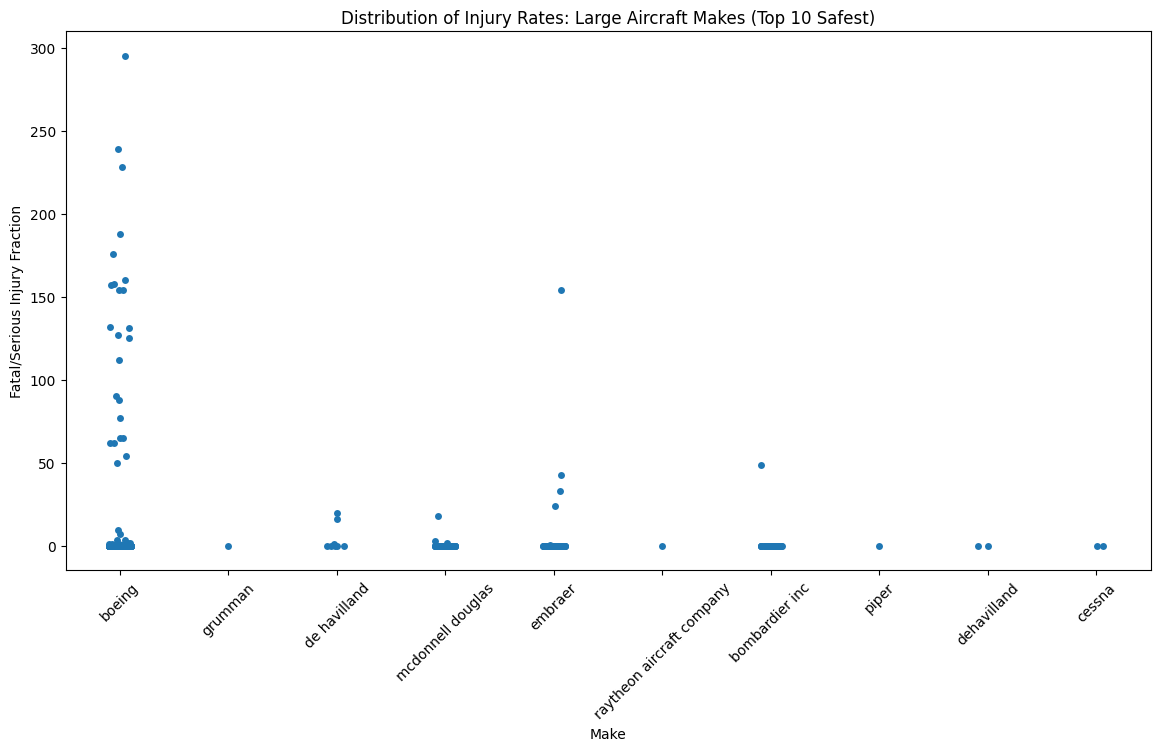

In [385]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.stripplot(
    data=large_top10,
    x="make",
    y="fatal_serious_inj",
    jitter=True
)

plt.title("Distribution of Injury Rates: Large Aircraft Makes (Top 10 Safest)")
plt.xlabel("Make")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.xticks(rotation=45)

plt.show()



**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

#### Destruction rate by make (small aircraft)

#### What these results mean
- A value close to 0 → very few aircraft of that make are destroyed
- A value closer to 1 → high likelihood of complete destruction in accidents
1. From the results, destruction rates tend to vary more widely and some makes may show 0.0 destruction rate

In [386]:
small_destruction = (
    small_planes.groupby("make")["aircraft_destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

small_destruction

,make,aircraft_destroyed
0,luscombe,0.014184
1,grumman acft eng cor-schweizer,0.017241
2,stinson,0.023256
3,taylorcraft,0.032258
4,aeronca,0.035000
5,american champion aircraft,0.038462
6,ercoupe,0.038462
7,aviat aircraft inc,0.039474
8,maule,0.041860
9,dehavilland,0.043011


#### Destruction rate by Make (Large aircraft)

#### What these results mean
- A value close to 0 → very few aircraft of that make are destroyed
- A value closer to 1 → high likelihood of complete destruction in accidents

1. From the results, we can see that destructions are more regulated and structurely robust. There is also lower and more consistent destruction rate

In [387]:
large_destruction = (
    large_planes.groupby("make")["aircraft_destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

large_destruction

,make,aircraft_destroyed
0,dehavilland,0.000000
1,cessna,0.000000
2,piper,0.000000
3,grumman,0.000000
4,raytheon aircraft company,0.000000
5,bombardier inc,0.022727
6,boeing,0.049360
7,embraer,0.051282
8,mcdonnell douglas,0.075472
9,airbus,0.076271


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### A brief discussion of aircraft  safety by Make
- The analysis used two key metrics: fatal/serious injury fraction and aircraft destruction rate, split into small (passengers < 20) and large aircraft.
#### Key Findings
- Across both groups, the top 15 safest makes consistently show low mean fatal/serious injury fractions, mostly close to zero, indicating that most incidents result in minimal or no serious harm. Large aircraft generally show more stable and lower variability in injury outcomes compared to small aircraft.
- The destruction rate analysis supports this pattern: several makes in both categories have very low destruction probabilities, with large aircraft again showing more consistent and lower rates overall.
#### Distribution Insights


1. Small aircraft (violin plot): wider variation in injury fractions, even among top makes, indicating occasional high-severity outliers.


2. Large aircraft (stripplot): tighter clustering near zero, suggesting more consistent safety performance across manufacturers.


#### Recommendations
Manufacturers that consistently show low injury fractions and low destruction rates (especially those appearing in the top 15 of both metrics) are the strongest candidates for recommendation. Large aircraft from these makes are generally safer and more predictable, while small aircraft require closer scrutiny due to higher variability.
#### Conclusion
Overall, aircraft make is strongly associated with safety outcomes. The safest makes demonstrate both low injury severity and low destruction rates, with large aircraft showing more stable and reliable safety profiles than small aircraft.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [388]:
# Filter valid models (≥ 10 records each)
valid_models = clean_airline["model"].value_counts()
valid_models = valid_models[valid_models >= 10].index

model_df = clean_airline[clean_airline["model"].isin(valid_models)].copy()

In [389]:
#Create plane type (small vs large)
model_df["plane_type"] = model_df["total_passangers"].apply(
    lambda x: "Small" if x < 20 else "Large"
)

In [390]:
#Mean fatal/serious injury fraction by plane type
type_means = (
    model_df.groupby("plane_type")["fatal_serious_inj"]
    .mean()
    .reset_index()
)

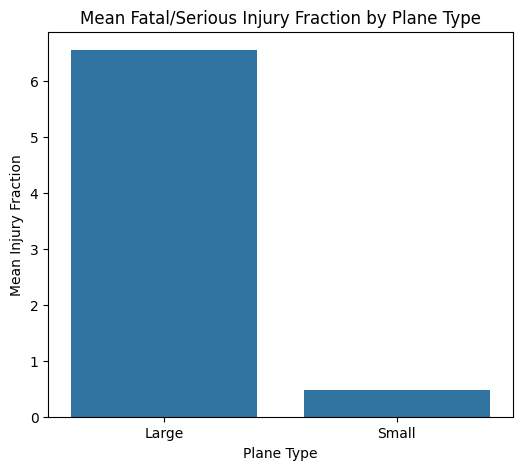

In [391]:
#Let plot the mean comparison 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.barplot(
    data=type_means,
    x="plane_type",
    y="fatal_serious_inj"
)

plt.title("Mean Fatal/Serious Injury Fraction by Plane Type")
plt.xlabel("Plane Type")
plt.ylabel("Mean Injury Fraction")

plt.show()

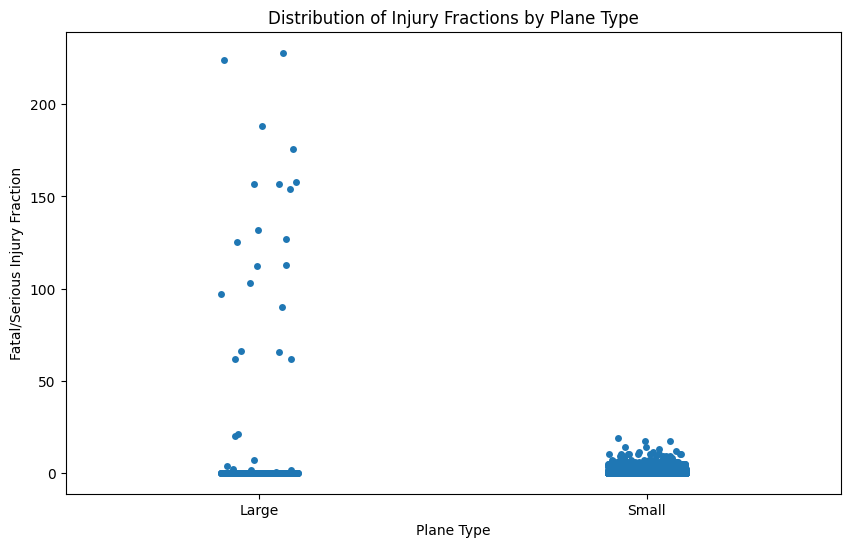

In [392]:
#Distribution plot between Plane type and fatal_serious_injuries
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=model_df,
    x="plane_type",
    y="fatal_serious_inj",
    jitter=True
)

plt.title("Distribution of Injury Fractions by Plane Type")
plt.xlabel("Plane Type")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [393]:
#compute mean injury per make
small_make_means = (
    small_planes.groupby("make")["fatal_serious_inj"]
    .mean()
    .sort_values()
    .reset_index()
)
top10_small_makes = small_make_means.head(10)
top10_small_makes

,make,fatal_serious_inj
0,mcdonnell douglas,0.191468
1,ayres,0.200617
2,aviat aircraft inc,0.203947
3,grumman acft eng cor-schweizer,0.206897
4,maule,0.245659
5,stinson,0.247416
6,aviat,0.257143
7,aeronca,0.264167
8,boeing,0.274240
9,bellanca,0.283866


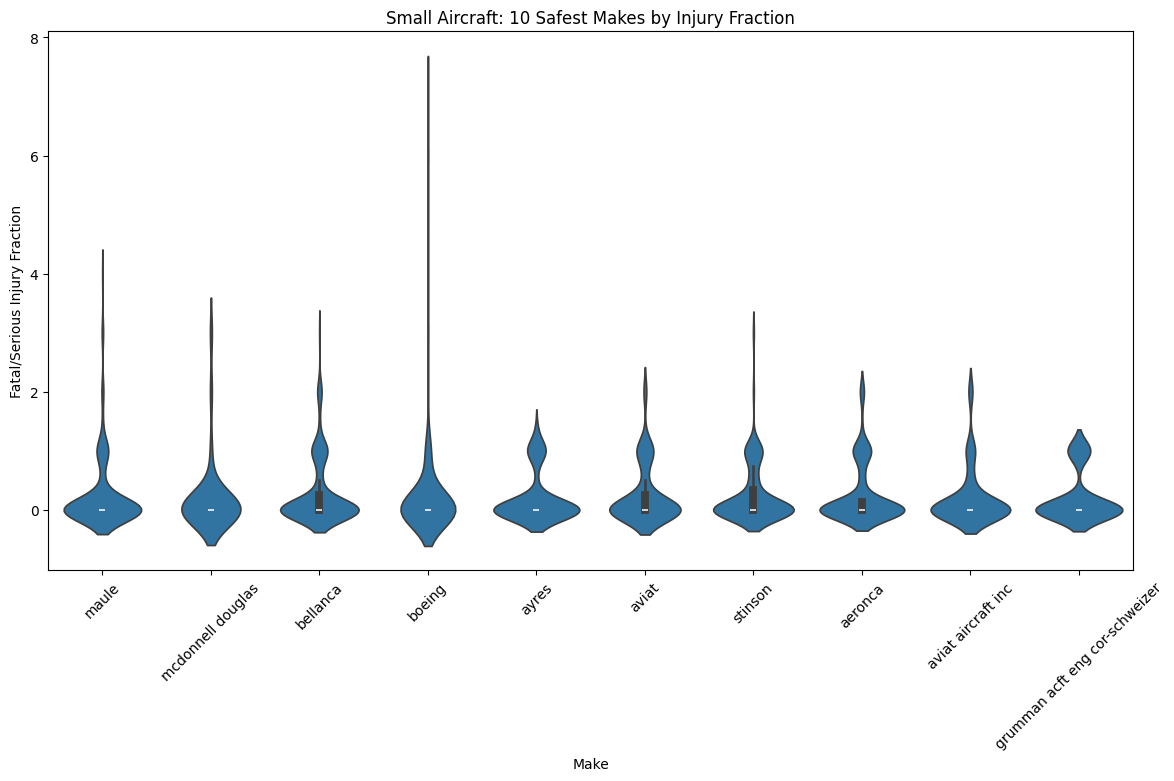

In [394]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.violinplot(
    data=small_top10,
    x="make",
    y="fatal_serious_inj"
)

plt.title("Small Aircraft: 10 Safest Makes by Injury Fraction")
plt.xlabel("Make")
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xticks(rotation=45)

plt.show()

observation: Only the safest 10 makes for small aircraft,Each violin shows:
- distribution of injury severity
- consistency of safety performance where 
Narrow + low = safest manufacturers

### Discussion
- From the observation Large aircraft generally show a lower and more consistent fatal/serious injury fraction, indicating better and more predictable safety performance. Small aircraft show higher variability, with some models performing well but others having occasional high injury rates.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Weather Condition vs Injury and Aircraft Damage

The analysis shows that weather condition has a clear impact on both injury severity and aircraft damage.

- Accidents in VMC (Visual Meteorological Conditions) are the most frequent but generally have lower fatal/serious injury fractions, likely because pilots have better visibility and control.

- In contrast, IMC (Instrument Meteorological Conditions) and adverse weather (rain, fog, storms) show higher injury severity and a higher proportion of aircraft destruction.


In general, Poor weather reduces visibility and increases operational difficulty, leading to more severe accident outcomes when incidents occur.

### Phase of Flight vs Injury and Aircraft Damage

The phase of flight strongly influences risk level.

- The highest injury and destruction rates occur during takeoff, landing, and approach phases.

- These phases are low altitude and high workload, leaving little time for recovery during emergencies.

- Cruise phase shows significantly lower fatal/serious injury fractions and lower destruction rates, as aircraft are more stable and at altitude.


This means, most severe accidents happen during critical transition phases, where pilot workload and environmental sensitivity are highest.